In [ ]:
import os
import sys
import gc
from pathlib import Path   
os.chdir('/zhome/71/c/146676/texture_tomography')
sys.path.append('/zhome/71/c/146676/texture_tomography/package/odf_mumott')
import h5py
import numpy as np

from package.texture_tomography.operators.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED

import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml

from package.odf_mumott.odftt.texture import grids


from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_huber_opencl import FISTAHuberOpenCL
from package.texture_tomography.gpu_live_tracker import GPUMemoryLogger
from package.texture_tomography.operators.operator_memory_model import OperatorMemoryModel
from package.texture_tomography.operators.memory_tracker import MemoryCounter
from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_memory_model import FISTAMemoryModel
from package.texture_tomography.material import Material
import pyopencl.array as clarray

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

from package.texture_tomography.operators.create_pfo_matrix import pfmatrix_sparseeval_gpu,sparse_pf_innerprod_gpu,interp_theta_4d_gpu, interp_theta_3d_gpu, build_pfsparse_program, sum_over_x_gpu, clip_nonnegative_gpu
import pyopencl as cl
from scipy.spatial.transform import Rotation as ROT

ModuleNotFoundError: No module named 'package.cil_addons'

In [ ]:
#config_path = "configs/aluminum_config_small.yaml"
config_path = "configs/bb_config_1.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

grid_resolution_parameter = cfg['grid_resolution_parameter']
kernel_sigma = cfg['kernel_sigma']
N_theta = cfg['N_theta']
min_two_theta = cfg['min_two_theta']
N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
Nx = cfg['Nx']
Ny = cfg['Ny']
peak_width = cfg['peak_width']
datapath = cfg["datapath"]
absorption_file = cfg['absorption_file']
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
N_seg = N_theta*N_chi
filename = cfg['integrated_file']
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']


In [2]:
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)

materials = []

for i_mat in range(N_mat):
    path = cif_folder / filenames[i_mat]
    material = Material.from_cif(
        cif_path=path,
        wavelength_kev=wavelength_kev,
        min_two_theta=min_two_theta,
        max_two_theta=max_two_theta,
        intensity_cutoff_fraction=reflection_cutoff,
    )
    materials.append(material)



NameError: name 'cif_path' is not defined

In [ ]:
grids_list = []
for i_mat in range(N_mat):
    pg = materials[i_mat].point_group_matrices
    pg_mats = pg.reshape(-1, 3, 3)
    pg_rotations = ROT.from_matrix(pg_mats)
    grid = grids.hopf_grid(7, pg_rotations)
    grids_list.append(grid)

In [3]:
with h5py.File(datapath + absorption_file, 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_all_events = dtc['all_events'][:].reshape(181,362)
    data_output_count_rate = dtc['output_count_rate'][:].reshape(181,362)
    data_att = dtc['window_counts'][:][:,0].reshape(181,362)


print('Loaded shape:', data_att.shape)



N_workers = 16  # adjust to match available CPUs

# --- Get list of dataset keys (exclude metadata) ---
with h5py.File(filename, 'r') as f:
    keys = [k for k in f.keys() if k != 'two_theta']
keys = sorted(keys, key=lambda x: int(x))


# --- Worker function ---
def load_single(key):
    with h5py.File(filename, 'r') as f:
        arr = f[key][...]
    return arr

with h5py.File(filename, 'r') as f:
    two_theta = f['two_theta'][:]


# --- Parallel load ---
with Pool(processes=N_workers) as pool:
    data_list = pool.map(load_single, keys)

# --- Combine into single array ---
data = np.stack(data_list, axis=0)

print('Loaded shape:', data.shape)
data_corrected = data/data_att[:,:,None,None]*100

Loaded shape: (181, 362)
Loaded shape: (181, 362, 90, 120)


In [4]:
all_data_reshaped = data_corrected.reshape((N_rot, Nx, N_chi*N_theta))

In [5]:
op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        materials=materials,
        grids=grids_list,
        two_thetas = two_theta,
        verbose=False)
op.set_pf_batch_max_gb(2.5)

mem = MemoryCounter()

#op_model = OperatorMemoryModel(op, mem)

# fista = FISTAOpenCL(
#     operator=op,
#     prox_kind="nonneg",
#     lam=0.0,
#     tau=1e-3
# )

# fista_mem = FISTAMemoryModel(fista, mem, op_model)

# x_shape  = (op.Nx, op.Ny, op.K_sum)
# Ax_shape = (op.N_rot, op.Nx, op.N_chi * op.N_theta)

# fista_mem.model_run(x_shape, Ax_shape, niter=1)

# mem.report()
# mem.report_peak_allocations(min_mb=50)

In [6]:
print(op.K_sum)
print(op.K_list)
print(op.K_sum*op.Nx*op.Ny*4/1e6)
print(op.K_sum*op.N_rot*op.Nx*4/1e6)
## todo: Implement varying ODF-resolution for different materials. Consider scaling... should the ODF scale accordingly? 

5547
[  58  689  202  202  689  192  689  344 1386  100  344  344   58   58
  192]
642.56448
1453.802136


[iter    1/20] obj=2.558072e+05  f=2.558072e+05  g=0.000000e+00  ||x||=1.245175e-04  ||grad||=1.245175e+07  tau=1.000e-11  beta=0.000e+00
[iter    2/20] obj=2.051889e+05  f=2.051889e+05  g=0.000000e+00  ||x||=2.252500e-04  ||grad||=1.009612e+07  tau=1.000e-11  beta=2.818e-01
[iter    3/20] obj=1.616596e+05  f=1.616596e+05  g=0.000000e+00  ||x||=3.263615e-04  ||grad||=7.350314e+06  tau=1.000e-11  beta=4.340e-01
[iter    4/20] obj=1.332807e+05  f=1.332807e+05  g=0.000000e+00  ||x||=4.157006e-04  ||grad||=4.733133e+06  tau=1.000e-11  beta=5.311e-01
[iter    5/20] obj=1.193481e+05  f=1.193481e+05  g=0.000000e+00  ||x||=4.870954e-04  ||grad||=2.816984e+06  tau=1.000e-11  beta=5.988e-01
[iter    6/20] obj=1.133249e+05  f=1.133249e+05  g=0.000000e+00  ||x||=5.399731e-04  ||grad||=1.852839e+06  tau=1.000e-11  beta=6.489e-01
[iter    7/20] obj=1.101508e+05  f=1.101508e+05  g=0.000000e+00  ||x||=5.771741e-04  ||grad||=1.550256e+06  tau=1.000e-11  beta=6.876e-01
[iter    8/20] obj=1.077208e+05  f

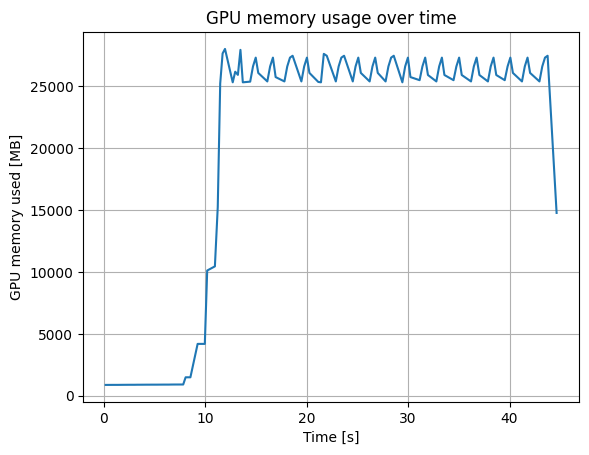

In [7]:
gpu_log = GPUMemoryLogger(interval=0.2, gpu_id=1)
gpu_log.start()


op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        materials=materials,
        grids = grids_list,
        two_thetas = two_theta,
        verbose=False)

queue = op.queue
Nx, Ny, K = op.Nx, op.Ny, op.K_sum

x0_gpu = clarray.zeros(
    queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous
op.set_pf_batch_max_gb(1.5)
# l1 constant: 1e7
# tv constant: 2e-6
# L constant for l1: 5e11
solver = FISTAHuberOpenCL(op, prox_kind="nonneg", lam=1e2, L=1e11, huber_delta=0.1)


x_sol_gpu = solver.run(x0_gpu, out_gpu, niter=20, verbose=1, diagnostics_interval=1)
coeffs = x_sol_gpu.get().transpose((0,1,2))[::-1,::-1]
# op.free_memory()
# del x_sol_gpu
# del out_gpu
# del x0_gpu
# gc.collect()

gpu_log.stop()

t, mem = gpu_log.as_arrays()
import matplotlib.pyplot as plt

plt.plot(t, mem)
plt.xlabel("Time [s]")
plt.ylabel("GPU memory used [MB]")
plt.title("GPU memory usage over time")
plt.grid(True)
plt.show()


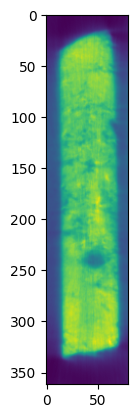

In [ ]:
plt.imshow(coeffs.sum(axis=-1))

(362, 80, 5547)
[  58  689  202  202  689  192  689  344 1386  100  344  344   58   58
  192]


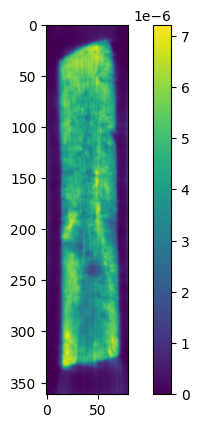

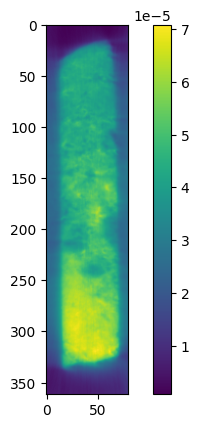

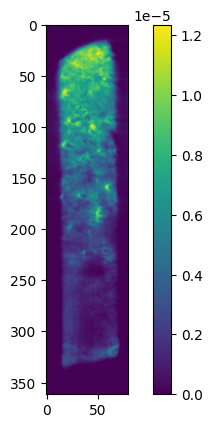

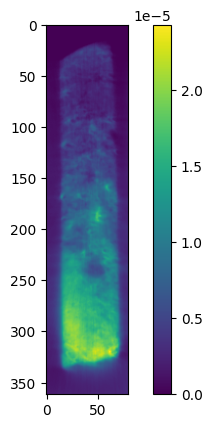

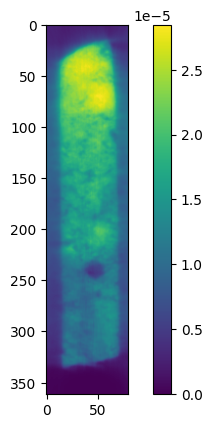

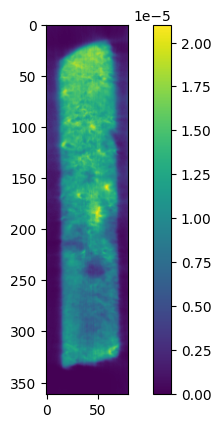

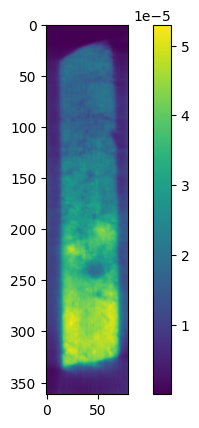

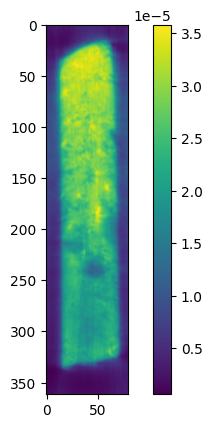

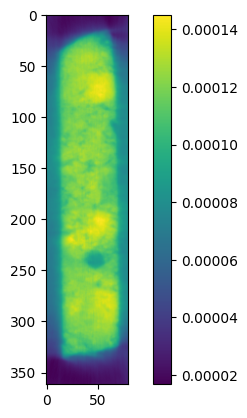

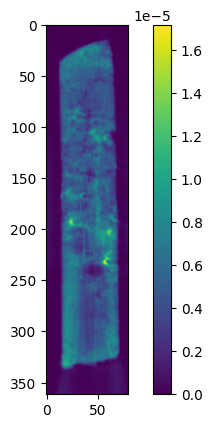

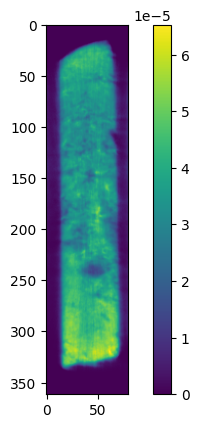

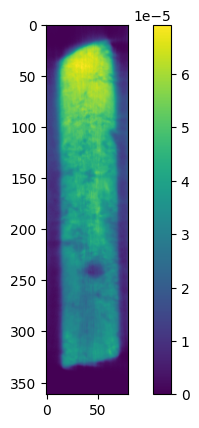

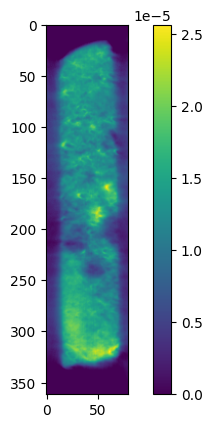

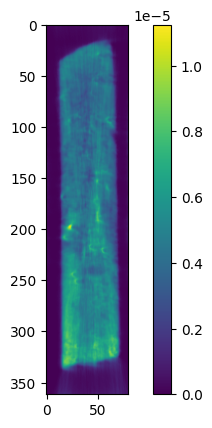

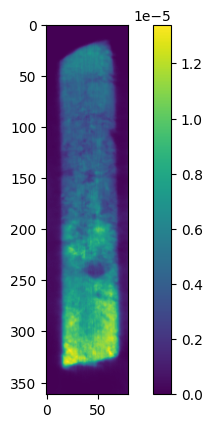

In [ ]:
print(coeffs.shape)
print(op.K_list)
cumult_K_list = np.cumsum(np.concatenate([np.array([0]), np.array(op.K_list)]))
for i in range(op.N_mat):
    plt.imshow(coeffs[:,:,cumult_K_list[i]:cumult_K_list[i+1]].sum(axis=-1))
    plt.colorbar()
    plt.show()

In [ ]:
print(cumult_K_list)

[   0   58  747  949 1151 1840 2032 2721 3065 4451 4551 4895 5239 5297
 5355 5547]


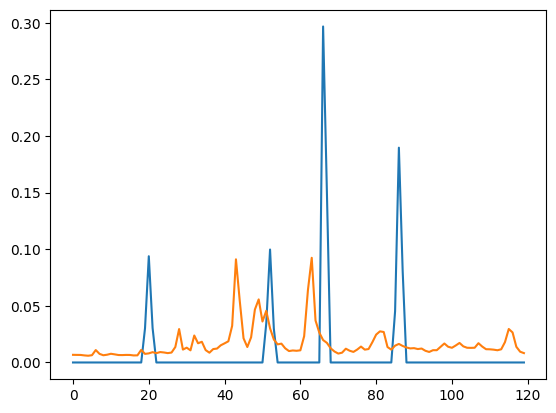

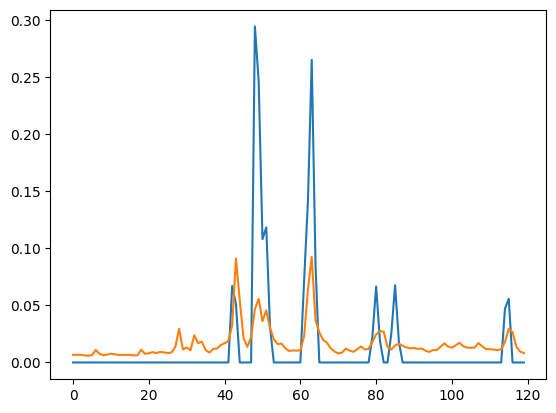

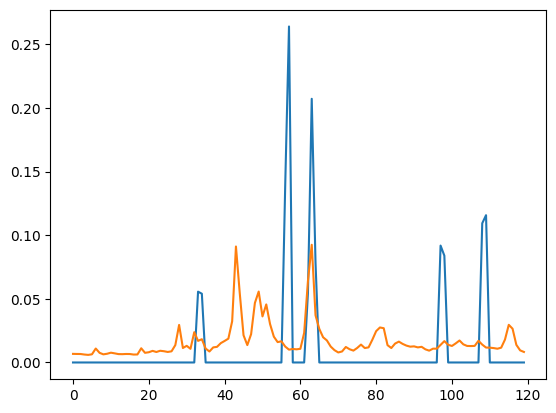

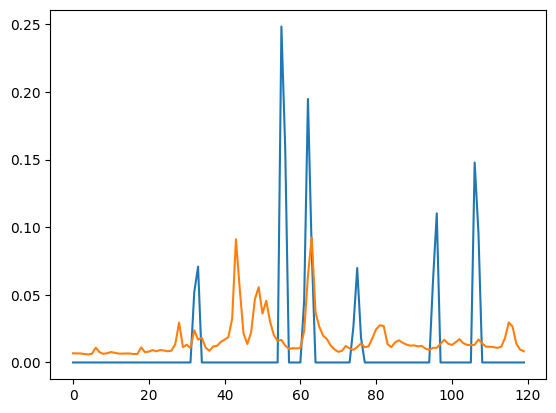

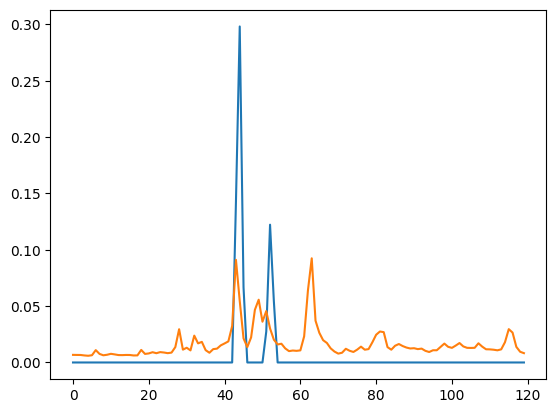

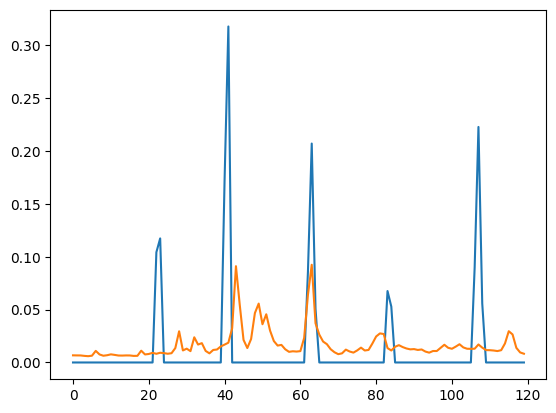

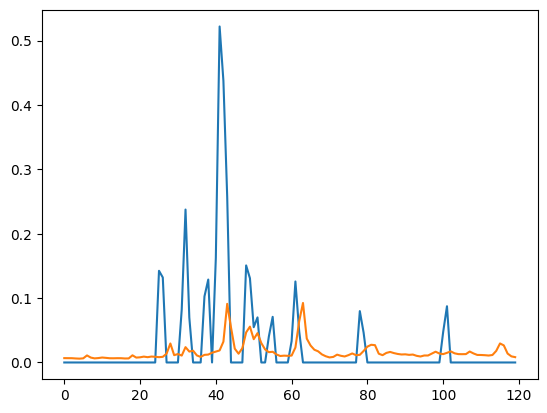

In [ ]:


for i_basis in range(op.N_mat-8):

    arr_basis = clarray.zeros(
        queue,
        (Nx, Ny, K),
        dtype=np.float32,
        order="F"
    )
    arr_basis[:, :, cumult_K_list[i_basis]:cumult_K_list[i_basis+1]].fill(1.0)
    out_basis = clarray.empty(
        queue,
        (N_rot, Nx, N_seg),
        dtype=np.float32,
        order="C",
    )

    op.direct_cl(arr_basis, out_basis)
    out_cpu = out_basis.get().reshape((N_rot, Nx, N_chi, N_theta))

    y_basis1 = out_cpu.sum(axis=(0,1,2))
    y_data = data_corrected.sum(axis=(0,1,2))
    plt.plot(y_basis1/5e12)
    plt.plot(y_data/y_data.sum()*2)
    plt.show()

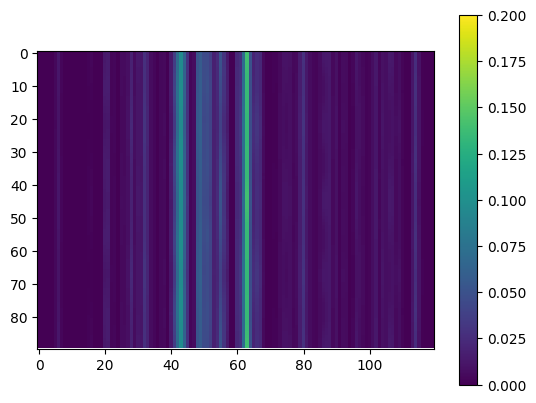

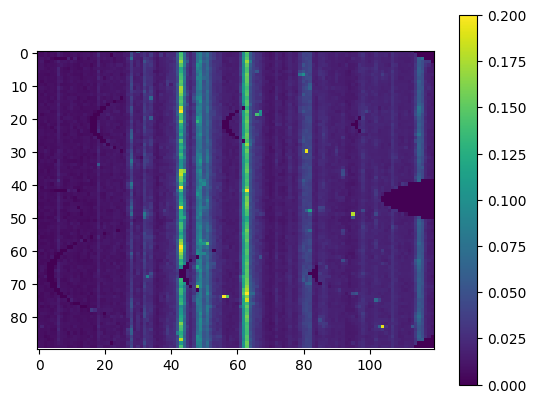

In [ ]:
pf_prg = build_pfsparse_program(op.ctx)
kernel_pfmatrix_count_sparse = cl.Kernel(pf_prg, "pfmatrix_count_sparse")
kernel_pfmatrix_write_sparse = cl.Kernel(pf_prg, "pfmatrix_write_sparse")
kernel_sparse_pf_innerprod_4d = cl.Kernel(pf_prg, "sparse_pf_innerprod_4d")
kernel_interp3d = cl.Kernel(pf_prg, "interp_theta_3d")
kernel_interp4d = cl.Kernel(pf_prg, "interp_theta_4d")
kernel_sum_over_x = cl.Kernel(pf_prg, "sum_over_x")
kernel_clip_nonnegative = cl.Kernel(pf_prg, "clip_nonnegative")

prediction_gpu = op.direct(x_sol_gpu)
prediction_cpu = prediction_gpu.get().reshape((N_rot, Nx, N_chi, N_theta))
res_gpu = out_gpu - prediction_gpu
clip_nonnegative_gpu(op.queue, kernel_clip_nonnegative, res_gpu)
res_gpu = res_gpu.reshape((N_rot, Nx, N_chi, N_theta))

plt.imshow(prediction_cpu[0,90])
plt.colorbar()
plt.clim([0,0.2])
plt.show()

plt.imshow(data_corrected[0,90])
plt.colorbar()
plt.clim([0,0.2])
plt.show()


## Multiresolution refinement

In [ ]:
from package.texture_tomography.multiresolution_refiner import OrientationTree, OrientationNode, generate_hopf_grid_fzone, invert_grid

In [ ]:
i_mat = 1
R = op.N_rot
pg = materials[i_mat].point_group_matrices
pg_mats = pg.reshape(-1, 3, 3)
pg_rotations = ROT.from_matrix(pg_mats)
grid = grids.hopf_grid(10, pg_rotations)
grid_inv = invert_grid(grid)
grid_inv_gpu = clarray.to_device(op.queue, grid_inv)

K = len(grid_inv)
C = op.N_chi
P = op.N_peaks_list[i_mat]
G = len(op.pf_sym_ops_cpu_list[i_mat])
sigma = op.kernel_sigma/3
cutoff = 2
sparse_pf = pfmatrix_sparseeval_gpu(
    op.queue,
    kernel_pfmatrix_count_sparse,
    kernel_pfmatrix_write_sparse,
    op.pf_coords_gpu_list[i_mat],
    grid_inv_gpu,
    op.pf_sym_ops_gpu_list[i_mat],
    op.pf_h_gpu_list[i_mat],
    R, K, C, P, G,
    sigma,
    cutoff
)

coo_k = sparse_pf['k'].get()
coo_r = sparse_pf['r'].get()
coo_c = sparse_pf['c'].get()
coo_p = sparse_pf['p'].get()
coo_val = sparse_pf['val'].get()

In [ ]:
theta_grid_gpu = clarray.to_device(op.queue, op.two_thetas)
theta_peaks_gpu = clarray.to_device(op.queue, op.peak_positions_np_list[i_mat])

res_peaks_gpu = clarray.empty(queue, (op.N_rot, op.Nx, op.N_chi, op.N_peaks_list[i_mat]), dtype=np.float32, order="C")


interp_theta_4d_gpu(
    op.queue,
    kernel_interp4d,
    res_gpu,
    res_peaks_gpu,
    theta_grid_gpu,
    theta_peaks_gpu,
    op.N_rot, op.Nx, op.N_chi, op.N_theta, op.N_peaks_list[i_mat],
)

res_peaks_gpu_summed = clarray.empty(queue, (op.N_rot, op.N_chi, op.N_peaks_list[i_mat]), dtype=np.float32, order="C")

sum_over_x_gpu(op.queue, kernel_sum_over_x, res_peaks_gpu, res_peaks_gpu_summed, op.N_rot, op.Nx, op.N_chi, op.N_peaks_list[i_mat])
res_peaks_cpu = res_peaks_gpu_summed.get()
res_peaks_cpu = res_peaks_cpu - res_peaks_cpu.mean(axis=1, keepdims=True)
res_peaks_cpu = np.clip(res_peaks_cpu, a_min=0, a_max = 10000000)

res_peaks_gpu_summed = clarray.to_device(op.queue, np.ascontiguousarray(res_peaks_cpu, dtype=np.float32))

IPs = sparse_pf_innerprod_gpu(
    op.queue,
    kernel_sparse_pf_innerprod_4d,
    sparse_pf,
    res_peaks_gpu_summed,
    op.N_rot,
    op.N_chi,
    op.N_peaks_list[i_mat],
    K,
)

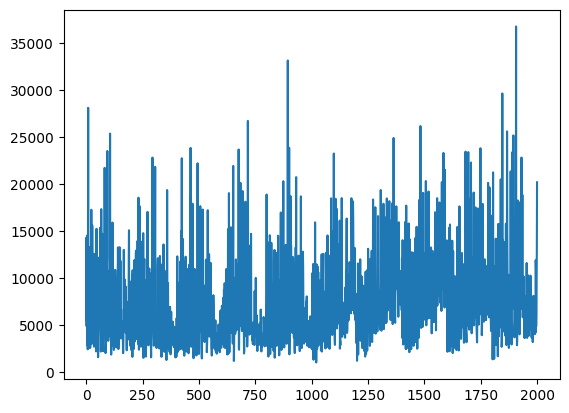

In [ ]:
plt.plot(IPs.get())

In [42]:
def sparse_slice_to_dense(
    coo_k,
    coo_r,
    coo_c,
    coo_p,
    coo_val,
    i_k,
    i_rot,
    N_chi,
    N_peaks,
):
    dense = np.zeros((N_chi, N_peaks), dtype=np.float32)

    mask = (coo_k == i_k) & (coo_r == i_rot)

    dense[coo_c[mask], coo_p[mask]] = coo_val[mask]

    return dense

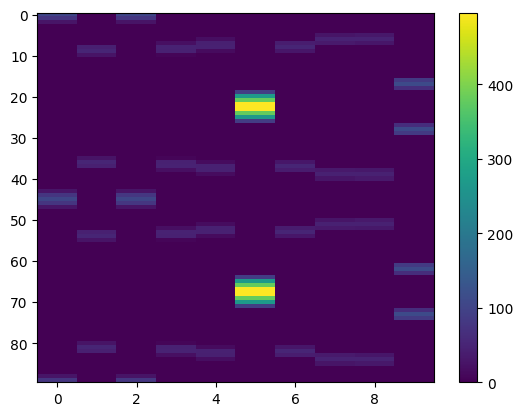

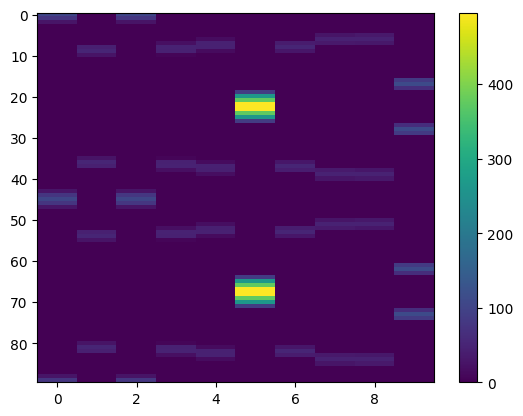

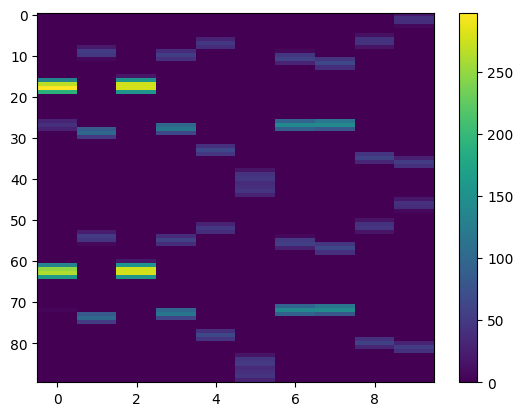

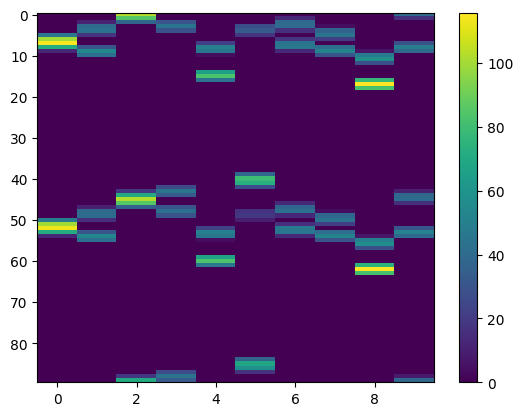

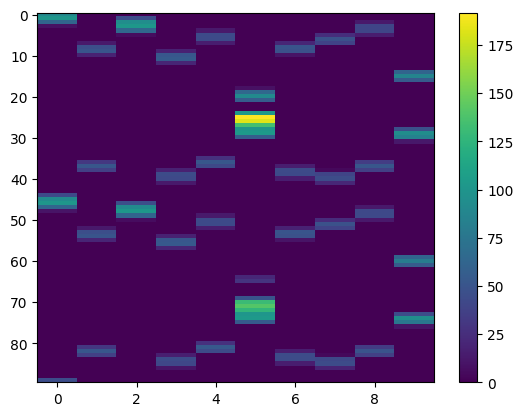

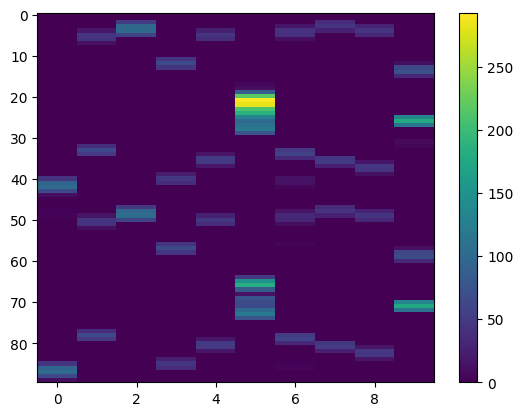

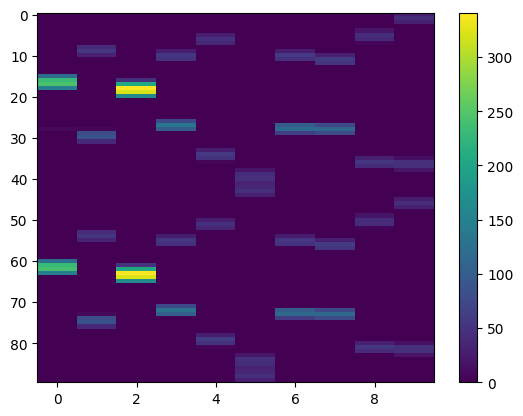

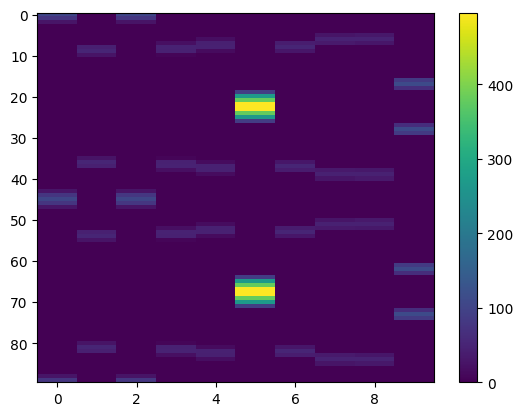

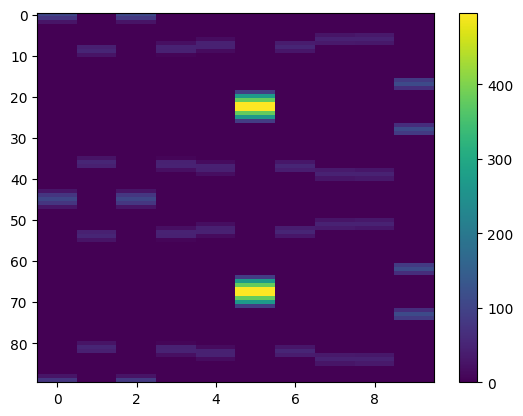

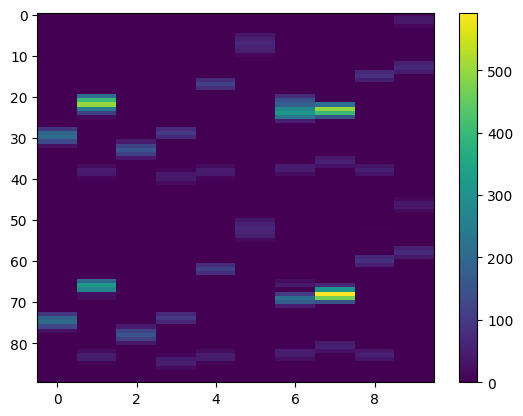

In [ ]:
best_orientation = np.argsort(IPs.get())[::-1]

for i in range(10):
    basis_slice = sparse_slice_to_dense(coo_k, coo_r,coo_c,coo_p,
                    coo_val, best_orientation[i],0,op.N_chi, op.N_peaks_list[i_mat])
    for i_rot in range(1,op.N_rot):
        basis_slice += sparse_slice_to_dense(coo_k, coo_r,coo_c,coo_p,
                    coo_val, best_orientation[i],i_rot,op.N_chi, op.N_peaks_list[i_mat])
                
    plt.imshow(basis_slice, aspect='auto')
    plt.colorbar()
    plt.show()



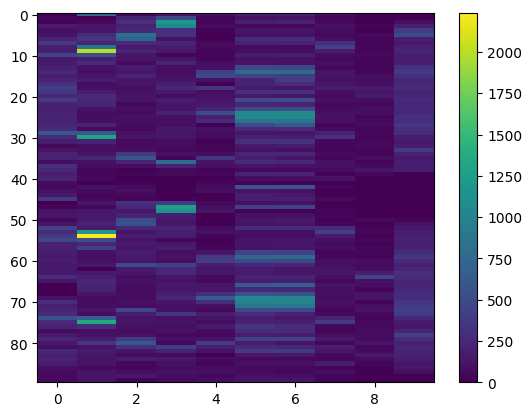

In [ ]:
plt.imshow(res_peaks_gpu_summed.get().sum(axis=0), aspect='auto')
plt.colorbar()

In [39]:
print(np.max(sparse_pf['val'].get()))

88.41941


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

<Figure size 640x480 with 0 Axes>

In [19]:
print(op.queue)
print(kernel_pfmatrix_count_sparse)
print(kernel_pfmatrix_write_sparse)
print(op.pf_coords_gpu_list[0])
print(op.pf_grid_inv_gpu_list[0])
print(op.pf_sym_ops_gpu_list[0])
print(op.pf_h_gpu_list[0])
print(R, K, C, P, G)
print(sigma)
print(cutoff)

[[[[-9.98396337e-01  2.77110650e-17 -5.66102490e-02]
   [-9.97861207e-01  2.76962122e-17 -6.53678849e-02]
   [-9.97325838e-01  2.76813527e-17 -7.30835199e-02]
   ...
   [-9.92494166e-01  2.75472469e-17 -1.22292116e-01]
   [-9.89799678e-01  2.74724598e-17 -1.42465994e-01]
   [-9.89259899e-01  2.74574779e-17 -1.46167040e-01]]

  [[-9.95964289e-01 -6.96446076e-02 -5.66102490e-02]
   [-9.95430470e-01 -6.96072802e-02 -6.53678849e-02]
   [-9.94896412e-01 -6.95699304e-02 -7.30835199e-02]
   ...
   [-9.90076482e-01 -6.92328885e-02 -1.22292116e-01]
   [-9.87388611e-01 -6.90449402e-02 -1.42465994e-01]
   [-9.86850142e-01 -6.90072849e-02 -1.46167040e-01]]

  [[-9.88680005e-01 -1.38949916e-01 -5.66102490e-02]
   [-9.88150120e-01 -1.38875440e-01 -6.53678849e-02]
   [-9.87619936e-01 -1.38800934e-01 -7.30835199e-02]
   ...
   [-9.82835293e-01 -1.38128489e-01 -1.22292116e-01]
   [-9.80167031e-01 -1.37753487e-01 -1.42465994e-01]
   [-9.79632497e-01 -1.37678370e-01 -1.46167040e-01]]

  ...

  [[-9.76579